
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_05_reg_multivariada_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5: Regresión multivariada

Supongamos que tenemos un conjunto de características $X = X_1, X_2,\ldots,X_j,\ldots,X_n$ para realizar una predicción $y$ con valores esperados $\hat{y}$.

Cada $X_j$ puede escribirse como:

$X_1 = x_1^{(1)},x_1^{(2)},x_1^{(3)},\ldots,x_1^{(m)}$,

$X_2 = x_2^{(1)},x_2^{(2)},x_2^{(3)},\ldots,x_2^{(m)}$,

.

.

.

$X_n = x_n^{(1)},x_n^{(2)},x_n^{(3)},\ldots,x_n^{(m)}$.

Siendo $n$ el número de características y $m$ el número de datos,
$\hat{y} = \hat{y}^{(1)},\hat{y}^{(2)},\ldots,\hat{y}^{(m)}$ el conjunto de valores etiquetados, y
$y = y^{(1)},y^{(2)},\ldots,y^{(m)}$ los valores predichos por un modelo.

Lo anterior puede resumirse como:

| Training | $\hat{y}$ | $X_1$ | $X_2$ | . | . | . | . | $X_n$ |
|--------|--------|------|------|---|---|---|---|------|
| 1 | $\hat{y}^{(1)}$ | $x_1^{(1)}$ | $x_2^{(1)}$ | . | . | . | . | $x_n^{(1)}$ |
| 2 | $\hat{y}^{(2)}$ | $x_1^{(2)}$ | $x_2^{(2)}$ | . | . | . | . | $x_n^{(2)}$ |
| . | . | . | . | . | . | . | . | . |
| . | . | . | . | . | . | . | . | . |
| . | . | . | . | . | . | . | . | . |
| m | $\hat{y}^{(m)}$ | $x_1^{(m)}$ | $x_2^{(m)}$ | . | . | . | . | $x_n^{(m)}$ |

y el modelo puede ajustarse como sigue:

Para un solo dato de entrenamiento tenemos que:

\begin{equation}
y = h(\theta_0,\theta_1,\theta_2,\ldots,\theta_n) = \theta_0 + \theta_1 x_1+\theta_2 x_2 + \theta_3 x_3 + \ldots + \theta_n x_n
\end{equation}

\begin{equation}
h_{\Theta}(x) =
[\theta_0,\theta_1,\ldots,\theta_n]
\begin{bmatrix}
1\\
x_1\\
x_2\\
\vdots\\
x_n
\end{bmatrix}
= \Theta^T X
\end{equation}

Para todo el conjunto de datos, tenemos que:

Sea $\Theta^T = [\theta_0,\theta_1,\theta_2,\ldots,\theta_n]$ una matriz $1 \times (n+1)$ y

\begin{equation}
X =
\begin{bmatrix}
1 & 1 & 1 & \cdots & 1\\
x_1^{(1)} & x_1^{(2)} & x_1^{(3)} & \cdots & x_1^{(m)}\\
x_2^{(1)} & x_2^{(2)} & x_2^{(3)} & \cdots & x_2^{(m)}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
x_n^{(1)} & x_n^{(2)} & x_n^{(3)} & \cdots & x_n^{(m)}
\end{bmatrix}_{(n+1)\times m}
\end{equation}

luego,

\begin{equation}
h = \Theta^T X
\end{equation}

con dimensión $1\times m$.

La anterior ecuación es un hiperplano en $\mathbb{R}^n$. Nótese que, en caso de tener una sola característica, la ecuación puede analizarse según lo visto en la sesión de regresión lineal.

Para la optimización, vamos a definir la función de coste $J(\theta_0,\theta_1,\theta_2,\ldots,\theta_n)$ como la función asociada a la mínima distancia entre los valores predichos y los valores esperados, según la métrica euclidiana.

- Métrica euclidiana

\begin{equation}
J(\theta_0,\theta_1,\theta_2,\ldots,\theta_n)=\frac{1}{2m} \sum_{i=1}^m \left( h_{\Theta}(x^{(i)})-\hat{y}^{(i)}\right)^2
\end{equation}

Otras métricas pueden definirse como se muestra en la siguiente referencia: [Metricas](https://jmlb.github.io/flashcards/2018/04/21/list_cost_functions_fo_neuralnets/).

Nuestro objetivo será encontrar los valores
$\Theta = (\theta_0,\theta_1,\theta_2,\ldots,\theta_n)$
que minimizan el error respecto a los valores etiquetados y esperados $\hat{y}$.

Para encontrar el $\Theta$ óptimo, se necesita minimizar la función de coste, lo que permite obtener los valores más cercanos. Esta minimización puede realizarse a través de diferentes métodos; el más conocido es el gradiente descendente.


## Gradiente descendente

Consideremos la función de coste sin realizar el promedio  de funcion de coste:
\begin{equation}
\Lambda^T =
\begin{bmatrix}
(\theta_0 1 + \theta_1 x_1^1+\theta_2 x_2^2 + \theta_3 x_3^3 +...+ \theta_n x_n^n - \hat{y}^{1})^2 \\
(\theta_0 1+ \theta_1 x_1^1+\theta_2 x_2^2 + \theta_3 x_3^3 +...+ \theta_n x_n^n - \hat{y}^{2})^2\\
.\\
.\\
.\\
(\theta_0 1 + \theta_1 x_1^m+\theta_2 x_2^m + \theta_3 x_3^m +...+ \theta_n x_n^m - \hat{y}^{m})^2\\
\end{bmatrix}
\end{equation}

$\Lambda= [\Lambda_1,\Lambda_2, ...,\Lambda_m]$

$J = \frac{1}{2m} \sum_{i}^m \Lambda_i $

El gradiente descente, puede ser escrito como:

\begin{equation}
\Delta \vec{\Theta} =  - \alpha \nabla J(\theta_0, \theta_1,...,\theta_n)
\end{equation}

escogiendo el valor j-esimo tenemos que:

\begin{equation}
\theta_j :=  - \alpha \frac{\partial J(\theta_0, \theta_1,...\theta_j...,\theta_n)}{\partial \theta_j}
\end{equation}

Aplicando lo anterior a a función de coste asociada a la métrica ecuclidiana, tenemos que:

Para $j = 0$,


\begin{equation}
\theta_0 :=  - \alpha \frac{\partial J(\theta_0, \theta_1,...\theta_j...,\theta_n)}{\partial \theta_0} = \frac{1}{m}\alpha \sum_{i=1}^m (\theta_j X_{ji} - \hat{y}^{(i)}) 1
\end{equation}



Para $0<j<n $

\begin{equation}
\theta_j :=  - \alpha \frac{\partial J(\theta_0, \theta_1,...\theta_j...,\theta_n)}{\partial \theta_j} = \frac{1}{m} \alpha\sum_{i=1}^m (\theta_{j} X_{ji} - \hat{y}^{(i)}) X_j
\end{equation}

donde X_j es el vector de entrenamiento j-esimo.

Lo  anterior puede ser generalizado como siguem, teniendo presente que $X_0 = \vec{1}$


Para $0\leq j<n$,

\begin{equation}
\theta_j :=  - \alpha \frac{\partial J(\theta_0, \theta_1,...\theta_j...,\theta_n)}{\partial \theta_j} = \frac{1}{m} \alpha\sum_{i=1}^m (\theta_j X_{ji} - \hat{y}^{(i)}) X_j
\end{equation}



# Vectorizando el grandiente descendete, tenemos que:
\begin{equation}
\nabla J = \Lambda^T X
\end{equation}

Luego:

\begin{equation}
\Theta=\Theta-\alpha \nabla J
\end{equation}



1. Para simular un conjunto de características $x_1$ , $x_2$,..., $x_n$ trabajaremos en la primera parte con dos características de datos aleatorios que presentan un plano y mostraremos que los párametros optimizados se corresponden con el valor esperado.

- Definir la ecuación  $y = 2.1*x_1 - 3.1*x_2$, y generar números aleatorios que pertenecen al plano.

- Realizar un diagrama 3D de los puntos generados aleatoriamente.


Nuestro objetivo será encontrar los valores $\theta_0 = 0, \theta_1=2.1, \theta_1=3.1$ que mejor ajustar el plano, empleando cálculos vectorizados.

2. Inicializar conjunto de parámetros $\Theta$ de manera aleatoria.
3. Construir la matrix X con dimensiones $(n+1, m)$, m es el numero de datos de entrenamiento y (n) el número de caracteristicas.
4. Calcular la función de coste(revise cuidosamente las dimensiones de cada matriz):

  - $h = \Theta^{T} X $
  - $\Lambda= (h -Y) $
  - $\Lambda*= (h -Y)^2 $
  - $\Lambda= [\Lambda_1,\Lambda_2, ...,\Lambda_m]$
  - $J = \frac{1}{2m} \sum_{i}^m \Lambda_i $

5. Aplicar el gradiente descendente:
  - Encontrar el gradiente.
    $\nabla J = \Lambda X.T$
  
  - Actualizar los nuevos parametros:
    $\Theta_{n+1}=\Theta_{n}-\alpha\nabla J$


6. Iterar para encontrar los valores $\Theta$ que se ajustan el plano.








7. Reescribir su código como una clase (ver ayuda)

## VECTORIZADO

In [20]:

import numpy as np
import matplotlib.pylab as plt
import pandas as pd
import plotly.graph_objects as go


# GENERAR DATOS ALEATORIOS
N = 100  # número de puntos de entrenamiento
# Generar características aleatorias x1 y x2 entre -1 y 1
x_1 = 2 * np.random.random(N) - 1 
x_2 = 2 * np.random.random(N) - 1

ruido = 0.5 * np.random.randn(N)
y_label = 2.1 * x_1 - 3.1 * x_2 + ruido


# MALLA
N = 100  # número de puntos en la malla
# Crear vectores lineales para x1 y x2
x1 = np.linspace(-1, 1, N)
x2 = np.linspace(-1, 1, N)

# Crear malla 2D a partir de los vectores
X_1, X_2 = np.meshgrid(x1, x2)

# Calcular z para la superficie (plano teórico)
Y = 2.1 * X_1 - 3.1 * X_2


# VISUALIZAR EN 3D
fig = go.Figure(go.Surface(
    x=X_1, 
    y=X_2, 
    z=Y,
    colorscale='viridis',  
    opacity=0.8,  
    showscale=True  
))

fig.add_trace(go.Scatter3d(
    x=x_1, 
    y=x_2, 
    z=y_label, 
    mode='markers', 
    marker=dict(size=5, color='navy', opacity=0.9),
    name='Puntos de entrenamiento'
))

fig.update_layout(
    title='Regresión Multivariada: Plano 3D',
    scene=dict(
        xaxis_title='x₁',
        yaxis_title='x₂',
        zaxis_title='y',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.3))
    ),
    width=1000,
    height=800
)

fig.show()





In [21]:
# PREPARAR DATOS PARA EL MODELO (J)
# df con los datos 
df = pd.DataFrame({"x1": x_1, "x2": x_2, "y": y_label})

# Agregar columna de unos para el término de theta_0
df["ones"] = 1


# CONSTRUIR MATRIZ X VECTORIZADA
# Matriz X de dimensión (3, 100): [ones, x1, x2]

X = df[["ones", "x1", "x2"]].values.T  # Transponer para obtener (3, 100)
Y = df.y.values.reshape(1, N)  # Convertir Y a dimensión (1, 100)

# Verificar dimensiones
Nfeatures = np.shape(X)[0]  # Número de características (incluyendo sesgo) = 3
m = np.shape(X)[1]  # Número de ejemplos de entrenamiento = 100
print(f"Dimensiones: {Nfeatures} características, {m} ejemplos")




Dimensiones: 3 características, 100 ejemplos


In [22]:
# FUNCIONES DEL MODELO
def model(theta, X):
    """
    Hipótesis: h = Theta^T * X
    Calcula las predicciones para todos los ejemplos
    """
    return theta.T @ X

def costo(h, Y):
    """
    Función de costo: J = (1/2m) * sum((h - Y)^2)
    h: predicciones (1, m)
    Y: valores reales (1, m)
    """
    J = (h - Y) ** 2
    return J.mean()  # Promedio del error cuadrático

def update_params(theta, h, Y, learning_rate):
    """
    Gradiente descendente vectorizado
    Calcula el gradiente: grad = (1/m) * (h - Y) * X^T
    Actualiza: theta = theta - learning_rate * grad
    """
    grad = np.dot((h - Y), X.T).T  # Dimensión (3, 1)
    theta = theta - learning_rate * grad
    return theta



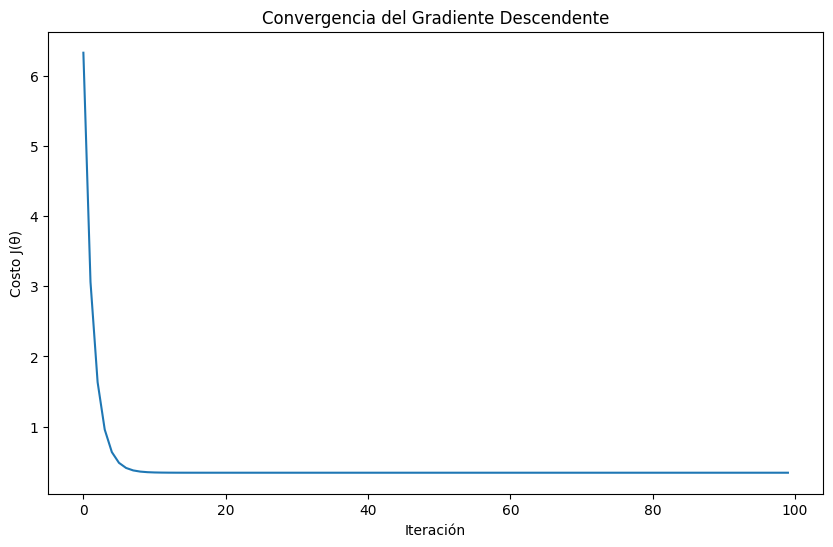


Parámetros optimizados:
θ₀ (sesgo) = -0.0858
θ₁ (coef x1) = 2.1287
θ₂ (coef x2) = -3.0609

Valores esperados: θ₀ ≈ 0, θ₁ ≈ 2.1, θ₂ ≈ -3.1


In [23]:
# INICIALIZAR PARÁMETROS Y ENTRENAR
# Inicializar theta aleatoriamente con dimensión (3, 1)
# theta = [theta_0, theta_1, theta_2]
theta = np.random.random(3).reshape(3, 1)

# Hiperparámetros
learning_rate = 0.01  # Tasa de aprendizaje
Niter = 100  # Número de iteraciones

# Almacenar el costo en cada iteración
J = np.zeros(Niter)


# ENTRENAMIENTO
for i in range(0, Niter):
    # Hacer predicción
    h = model(theta, X)
    
    # Calcular y almacenar costo
    J[i] = costo(h, Y)
    
    # Actualizar parámetros
    theta = update_params(theta, h, Y, learning_rate)


# Graficar cómo disminuye el costo con cada iteración
plt.figure(figsize=(10, 6))
plt.plot(J)
plt.xlabel('Iteración')
plt.ylabel('Costo J(θ)')
plt.title('Convergencia del Gradiente Descendente')
plt.show()


print(f"\nParámetros optimizados:")
print(f"θ₀ (sesgo) = {theta[0, 0]:.4f}")
print(f"θ₁ (coef x1) = {theta[1, 0]:.4f}")
print(f"θ₂ (coef x2) = {theta[2, 0]:.4f}")
print(f"\nValores esperados: θ₀ ≈ 0, θ₁ ≈ 2.1, θ₂ ≈ -3.1")

## CLASE

In [24]:
class MultilinearRegresion():

  def __init__(self, X, Y):
    """    
    X : array de dimensión (n_features, m)
        Matriz de características (esta es la matriz de la columna de unos)
    Y : array de dimensión (1, m)
        Vector de valores objetivo
    """
    self.X = X
    self.Y = Y
    self.Nfeatures = np.shape(X)[0]  
    self.m = np.shape(X)[1]          
    self.theta = np.random.random(self.Nfeatures).reshape(self.Nfeatures, 1)
    self.J_history = []  # Almacenamiento

  def h_valor(self):
    """
    Calcular la predicción: h = Theta^T * X
    """
    self.h = self.theta.T @ self.X

  def costo(self):
    """
    Calcular la función de costo: J = (1/m) * sum((h - Y)^2)
    """
    error = (self.h - self.Y) ** 2
    self.J = error.mean()

  def update_params(self, learning_rate):
    """
    Actualización de parametros
    
    Gradiente: grad = (h - Y) * X^T
    Actualización: theta = theta - learning_rate * grad
    """
    grad = np.dot((self.h - self.Y), self.X.T).T
    self.theta = self.theta - learning_rate * grad

  def fit(self, learning_rate=0.01, num_iterations=100):
    """
    Entrenamiento de modelo   
    
    learning_rate (alpha): Tasa de aprendizaje (por defecto 0.01)
    num_iterations : Número de iteraciones (por defecto 100)
    
    """
    self.J_history = []
    
    for i in range(num_iterations):
      self.h_valor()      # Predicción
      self.costo()        # Cálculo del costo
      self.J_history.append(self.J)  # Guardar costo
      self.update_params(learning_rate)  # actualizar parámetros
    
    return self
  
  def predict(self, X_new):
    """
    Realizar predicciones con datos nuevos

    X_new : array de dimensión (n_features, n_samples)
        Nuevas características para predicción
    

    predictions : array
        Predicciones para los nuevos datos
    """
    return self.theta.T @ X_new
  
  def get_params(self):
    """
    theta : Vector de parámetros [theta_0, theta_1, ..., theta_n]
    """
    return self.theta.flatten()

Tomamos los datos con los que hicimos la primera parte dek ejercicio para ver que de lo mismo 

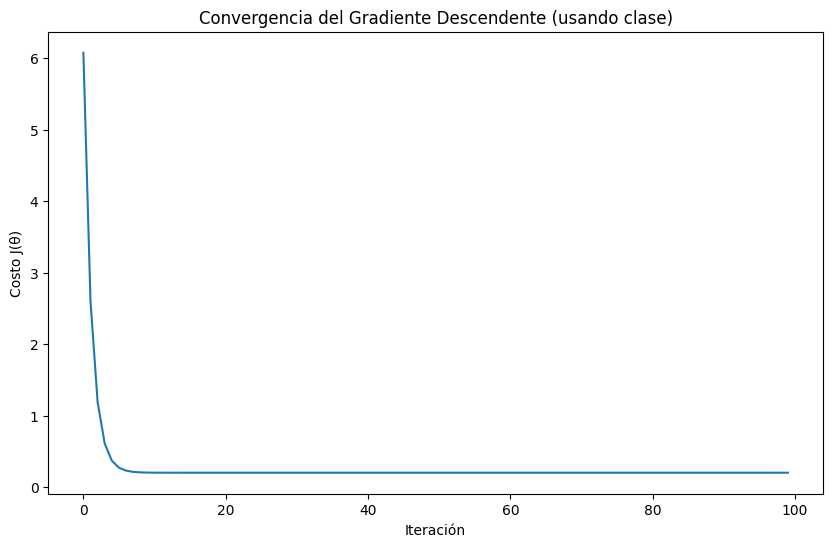

In [25]:
N = 100
x_1 = 2 * np.random.random(N) - 1 
x_2 = 2 * np.random.random(N) - 1
ruido = 0.5 * np.random.randn(N)
y_label = 2.1 * x_1 - 3.1 * x_2 + ruido

df = pd.DataFrame({"x1": x_1, "x2": x_2, "y": y_label})
df["ones"] = 1

X = df[["ones", "x1", "x2"]].values.T  # (3, 100)
Y = df.y.values.reshape(1, N)          # (1, 100)

#Aplicar la clase que se creó
modelo = MultilinearRegresion(X, Y)

modelo.fit(learning_rate=0.01, num_iterations=100)

plt.figure(figsize=(10, 6))
plt.plot(modelo.J_history)
plt.xlabel('Iteración')
plt.ylabel('Costo J(θ)')
plt.title('Convergencia del Gradiente Descendente (usando clase)')
plt.show()

